In [61]:
#1.1 Loading the data
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from sklearn.linear_model import LinearRegression
import numpy as np

In [ ]:
#1.1 Loading the data
state_df = pd.read_csv("../data/stateCoord.csv")
arrest_df = pd.read_csv("../data/USArrests.csv")

In [6]:
state_df.head() 

,State,lon,lat
0,Alabama,-86.592392,34.735676
1,Alaska,-168.187471,53.330810
2,Arizona,-111.615136,36.246377
3,Arkansas,-92.240455,36.374502
4,California,-120.386476,34.034180


In [7]:
arrest_df.head()

,State,Murder,Assault,UrbanPop,Rape
0,Alabama,13.2,236,58,21.2
1,Alaska,10.0,263,48,44.5
2,Arizona,8.1,294,80,31.0
3,Arkansas,8.8,190,50,19.5
4,California,9.0,276,91,40.6


In [31]:
#remove whitespace from column names
print(arrest_df.columns.tolist())
print(state_df.columns.tolist())
state_df.columns = state_df.columns.str.strip()
print(state_df.columns.tolist())
print(arrest_df["State"].head(10).tolist())
print(state_df["State"].head(10).tolist())
state_df["State"] = state_df["State"].str.strip()
print(state_df["State"].head(10).tolist())

['State', 'Murder', 'Assault', 'UrbanPop', 'Rape']
['State', 'lon', 'lat']
['State', 'lon', 'lat']
['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut', 'Delaware', 'Florida', 'Georgia']
['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut', 'Delaware', 'Florida', 'Georgia']
['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut', 'Delaware', 'Florida', 'Georgia']


In [32]:
#1.2 Manipulating the data
arrests = pd.merge(arrest_df, state_df, how='inner', on="State")

arrests.head()

,State,Murder,Assault,UrbanPop,Rape,lon,lat
0,Alabama,13.2,236,58,21.2,-86.592392,34.735676
1,Alaska,10.0,263,48,44.5,-168.187471,53.330810
2,Arizona,8.1,294,80,31.0,-111.615136,36.246377
3,Arkansas,8.8,190,50,19.5,-92.240455,36.374502
4,California,9.0,276,91,40.6,-120.386476,34.034180


Text(0, 0.5, 'Assault')

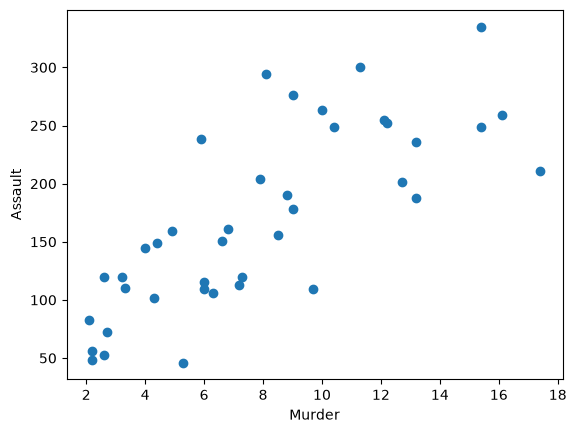

In [45]:
#1.3 Visualizing the data

## Plot “Murder” vs “Assault” 
plt.scatter(arrests["Murder"], arrests["Assault"])

plt.xlabel("Murder")
plt.ylabel("Assault")


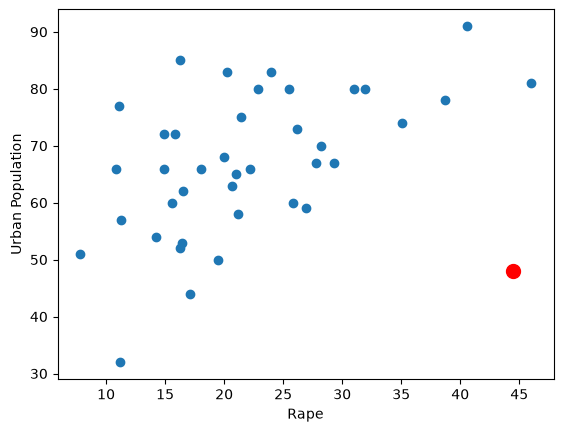

In [ ]:
##Plot “Rape” vs “urban population”
plt.scatter(arrests["Rape"], arrests["UrbanPop"])

plt.xlabel("Rape")
plt.ylabel("Urban Population")

###label outlier with a different color
outlier = arrests[arrests["State"] == "Alaska"]
plt.scatter(outlier["Rape"], outlier["UrbanPop"], c="red", s=100)

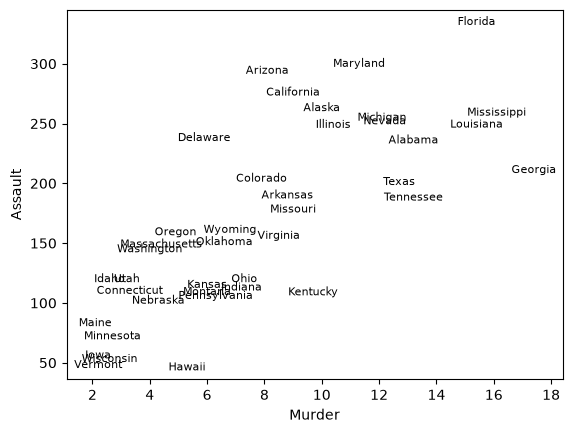

In [ ]:
##Re-make plots with state names instead of points 
plt.xlabel("Murder")
plt.ylabel("Assault")

#state names instead of points
for _, row in arrests.iterrows():
    plt.annotate(row["State"], (row["Murder"], row["Assault"]), fontsize=8, ha='center', va='center')

#since there's no scatter call to auto-scale axes, set limits manually with some padding
plt.xlim(arrests["Murder"].min() - 1, arrests["Murder"].max() + 1)
plt.ylim(arrests["Assault"].min() - 10, arrests["Assault"].max() + 10)

plt.show()

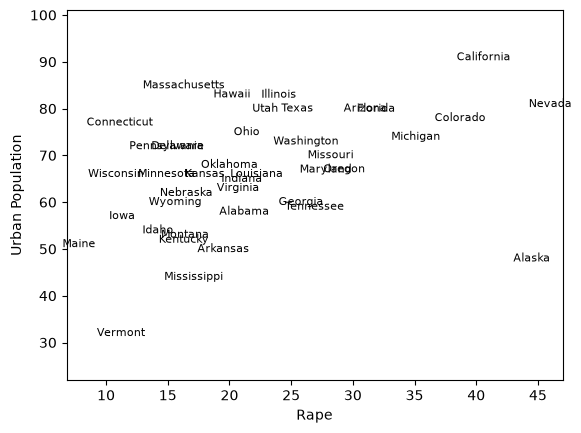

In [ ]:
##Re-make plots with state names instead of points 
plt.xlabel("Rape")
plt.ylabel("Urban Population")

#state names instead of points
for _, row in arrests.iterrows():
    plt.annotate(row["State"], (row["Rape"], row["UrbanPop"]), fontsize=8, ha='center', va='center')

#since there's no scatter call to auto-scale axes, set limits manually with some padding
plt.xlim(arrests["Rape"].min() - 1, arrests["Rape"].max() + 1)
plt.ylim(arrests["UrbanPop"].min() - 10, arrests["UrbanPop"].max() + 10)

plt.show()

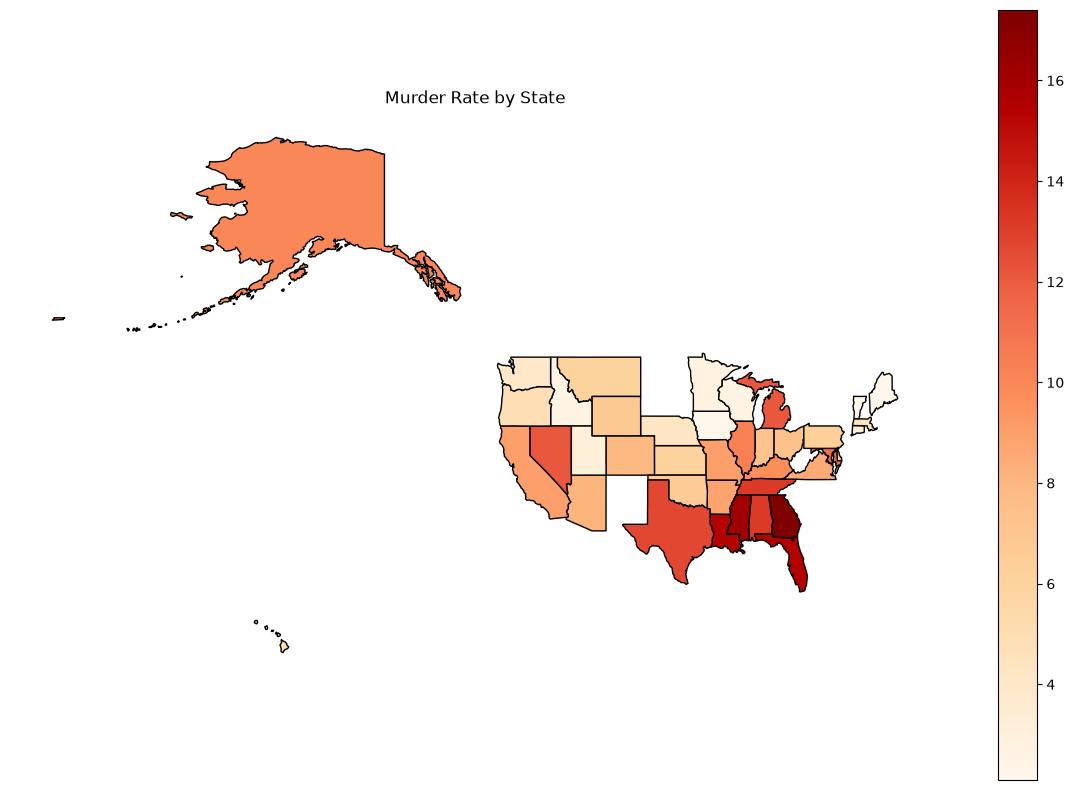

In [ ]:
##Challenge: Plot a map of the US colouring each state by its “Murder” rate. Check out geopandas.
states_geo = gpd.read_file(
    "https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json"
)merged = states_geo.merge(arrests, left_on="name", right_on="State", how="inner")
fig, ax = plt.subplots(figsize=(15, 10))
merged.plot(column="Murder", ax=ax, legend=True, cmap="OrRd", edgecolor="black")
ax.set_title("Murder Rate by State")
ax.axis("off")
plt.show()

Intercept: 54.10989148790316
Coefficient (Rape): 0.5603074549219779
R^2: 0.16552726248422334


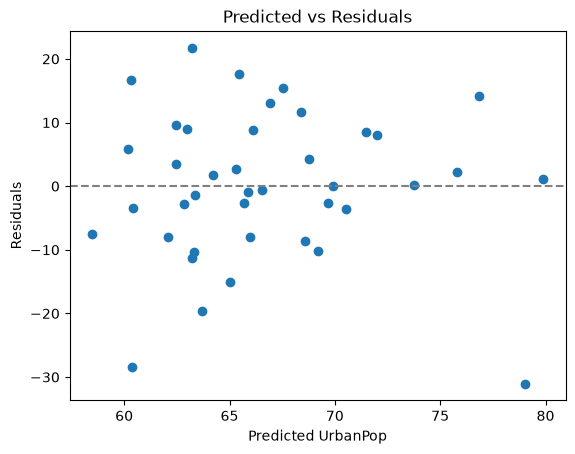

In [ ]:
#1.4 Regression

##Remove the “Murder” and “Assault” columns from the arrests DataFrame (you can index a DataFrame with multiple column names!)
arrests_reduced = arrests.drop(columns=["Murder", "Assault"])
arrests_reduced.head()

##Fit a linear regression of “UrbanPop” on “Rape”
X = arrests_reduced[["Rape"]]      # predictor — needs to be 2D, hence double brackets
y = arrests_reduced["UrbanPop"]    # response variable

reg = LinearRegression()
reg.fit(X, y)

print("Intercept:", reg.intercept_)
print("Coefficient (Rape):", reg.coef_[0])
print("R^2:", reg.score(X, y))

##Plot predicted values versus the residuals.
predicted = reg.predict(X)
residuals = y - predicted

plt.scatter(predicted, residuals)
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel("Predicted UrbanPop")
plt.ylabel("Residuals")
plt.title("Predicted vs Residuals")
plt.show()

/Users/miadenning/miniconda3/envs/215a/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


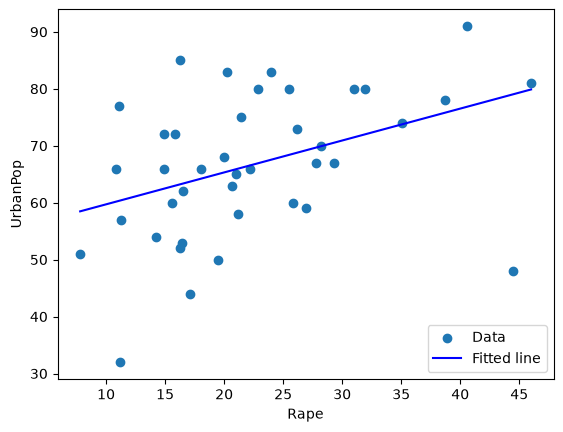

In [62]:
##Replot “Rape” vs “UrbanPop” and draw a blue line with the predicted responses
plt.scatter(arrests_reduced["Rape"], arrests_reduced["UrbanPop"], label="Data")

x_sorted = np.sort(arrests_reduced["Rape"].values).reshape(-1, 1)
y_pred_sorted = reg.predict(x_sorted)
plt.plot(x_sorted, y_pred_sorted, color="blue", label="Fitted line")

plt.xlabel("Rape")
plt.ylabel("UrbanPop")
plt.legend()
plt.show()

/Users/miadenning/miniconda3/envs/215a/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


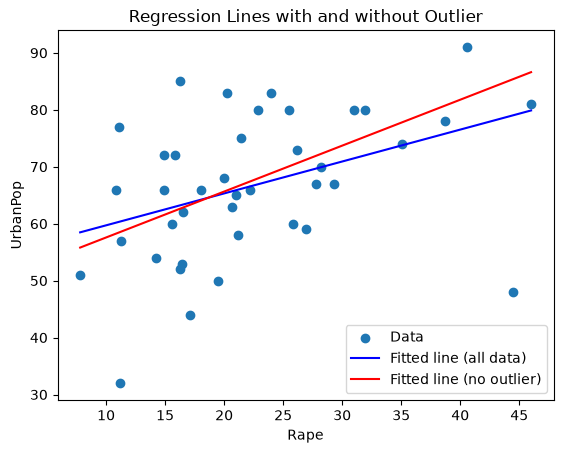

In [64]:
outlier_state = "Alaska"   # replace with the state you identified visually

arrests_no_outlier = arrests_reduced[arrests_reduced["State"] != outlier_state]

X_no = arrests_no_outlier[["Rape"]]
y_no = arrests_no_outlier["UrbanPop"]

reg_no_outlier = LinearRegression()
reg_no_outlier.fit(X_no, y_no)

# same plot as question 4, with the new fit added in red
plt.scatter(arrests_reduced["Rape"], arrests_reduced["UrbanPop"], label="Data")
plt.plot(x_sorted, y_pred_sorted, color="blue", label="Fitted line (all data)")

x_sorted_no = np.sort(X_no["Rape"].values).reshape(-1, 1)
y_pred_no = reg_no_outlier.predict(x_sorted_no)
plt.plot(x_sorted_no, y_pred_no, color="red", label="Fitted line (no outlier)")

plt.xlabel("Rape")
plt.ylabel("UrbanPop")
plt.title("Regression Lines with and without Outlier")
plt.legend()
plt.show()